# Section 2: Data Preparation & Feature Engineering  --> Chapter 6: Data Quality Engineering

---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)

**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
# In case you need to install the relevent packages, please uncomment lines below and run (once only)

# !pip install scikit-learn==1.2.2
# !pip install pandas==2.0.3
# !pip install numpy==1.25.2
# !pip install matplotlib==3.7.1
# !pip install pydrive2==1.6.3
# !pip install IPython==7.34.0
# !pip install seaborn==0.13.1
# !pip install scipy==1.11.4
# !pip install google.colab
# !pip install pydrive2==1.6.3
# !pip install oauth2client==4.1.3

---

☑ **Import libraries**

---

In [ ]:
# Set some common environment variables and Imports
import numpy as np
import pandas as pd  # Import pandas module for data manipulation
import warnings  # Warnings
from IPython.core.display import display, HTML  # Make the Jupyter chunk window wider
import gzip

from scipy.stats import mstats  # Import winsorization from scipy.stats

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)  # Setting to display all columns in a single row
display(HTML("<style>.container { width:100% !important; }</style>")) # Make the Jupyter chunk window wider

from pydrive2.auth import GoogleAuth  # Import GoogleAuth class from the pydrive2.auth module
from pydrive2.drive import GoogleDrive  # Import GoogleDrive class from the pydrive2.drive module
from google.colab import auth  # Import auth class from the google.colab module
from oauth2client.client import GoogleCredentials  # Import GoogleCredentials class from the oauth2client.client module

from tabulate import tabulate  # Adjust CSS style for output wrapper to prevent text wrapping in preformatted text

from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split  # Importing train_test_split function from sklearn

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Quality Engineering


In [ ]:
# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

#####**Step 1a:** Extract the data again(if you have not done that in Chapter 5).


In [ ]:
def get_data(colabFileName, fileLink):
    try:
        # Authenticate and create the PyDrive client.
        auth.authenticate_user()  # Authenticate the user
        gauth = GoogleAuth()  # Create a GoogleAuth instance
        gauth.credentials = GoogleCredentials.get_application_default()  # Use the default application credentials
        drive = GoogleDrive(gauth)  # Create a GoogleDrive instance using the authenticated GoogleAuth instance

        # Read File
        ignorestr, id = fileLink.split('=')  # Split the link by '=' and get the id of the file
        downloaded = drive.CreateFile({'id':id})  # Create a PyDrive File instance with the specified file id
        downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
        df = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
        return df  # Return the Pandas dataframe
    except Exception as e:
        logging.error(f"Failed to get data: {e}")
        raise
        return None

# Read the file and display contents.
print_pretty_header("Extract Data for Data Quality Engineering", "All Data")
colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
df_rawdata = get_data(colabFileName, dataLink)  # Call the get_data() function
df_rawdata_org = df_rawdata.copy()  # Make a copy of the Pandas dataframe for ease of dropping columns
df_rawdata  # Display the Pandas dataframe containing the data.


####################################################################################################

                             Extract Data for Data Quality Engineering                              

                                              All Data                                              

####################################################################################################



,VacationHomeID,VacHomeClass,VacHomeZone,VacHomeLotFrontage,VacHomeLotSqFt,VacHomeStreet,VacHomeRoad,VacHomeLotShape,VacHomeLandContour,VacHomeUtilities,VacHomeLotConfig,VacHomeLandSlope,VacHomeNeighborhood,VacHomeCondition,VacHomeBuilding,VacHomeHouseStyle,VacHomeRating,VacHomeQuality,VacHomeConsYear,VacHomeSince,VacHomeRoofStyle,VacHomeRoofMat,VacHomeExterior,VacHomeMasonryVeneer,VacHomeMasonryArea,VacHomeExterQual,VacHomeQual,VacHomeFoundation,VacHomeBsmtQuality,VacHomeBsmtLight,VacHomeBsmtFinish,VacHomeBsmtSqFt,VacHomeHeating,VacHomeHeatingQuality,VacHomeAC,VacHomeElectricalWiring,VacHomeFloor1SqFt,VacHomeFloor2SqFt,VacHomeSqFt,VacHomeNumFullBath,VacHomeNumHalfBath,VacHomeBedroomWithCloset,VacHomeKitcheninHome,VacHomeKitchenQuality,VacHomeRooms,VacHomeFireplaces,VacHomeFireplaceQuality,VacHomeGarageType,VacHomeGarageFinish,VacHomeCarsInGarage,VacHomeGarageArea,VacHomeGarageQuality,VacHomeDriveway,VacHomeWoodDeckSqFt,VacHomePorchSqFt,VacHomePoolSqFt,VacHomePoolQuality,VacHomeFence,VacHomeStartMonth,VacHomeStartYear,VacHomeSaleType,VacHomeSaleCondition,VacHomeSalePrice,VacHomeInterestInHome,VacHomeGoodSchools,VacHomeAvailableDate,VacHomeBarCode,VacHomeOwnerAddress,VacHomeOwnerCity,VacHomeOwnerCountry,VacHomeOwnerEmail,VacHomeOwnerGender,VacHomeOwnerState,VacHomeOwnerZipcode,VacHomeRenovationAmount,VacHomeSurveyDate,VacHomeSurveyRating,VacHomeReviewDate,VacHomeReviewRating
0,1,VacHomeClass-6,VacHomeZone-1,65.0,8450,Cobblestone,Gravel,Pie,Flat,Trash|Gas|Water|Electricity,Interior lot,No Slope,RNH 6,Proximity to School,Apartment,Bungalow,7,5,2008,2009,Gable,Rolled Roofing,Board Batten,Natural Stone,196.0,4,3,Individual footing,4.0,No Sunlight,ZenWall Panels,856,Furnace,5,Yes,NM Cable,856,854,1710,2,1,3,1,4,8,0,NaN,Attached,Wood Sheathing,2,548,3,Paved,0,0,0,0,No Fence,2,2008,Down payment assistance,Regular,173061.00,Y,Y,2021-11-24,78408012,Jochen-Peukert-Straße 4/7\n93824 Wolgast,Schwandorf,Venezuela,sylvester59@haase.de,M,Niedersachsen,41157,93.0,2021-11-24,4.6,2021-11-24,4.6
1,2,VacHomeClass-1,VacHomeZone-1,80.0,9600,Cobblestone,Gravel,Pie,Flat,Trash|Gas|Water|Electricity,T-intersection,No Slope,RNH 25,Proximity to Hospital,Apartment,Contemporary,6,8,1977,1979,Gable,Rolled Roofing,Log Wood,Manmade Stone,0.0,3,3,Combined footing,4.0,French Doors,BrightWall Paneling,1262,Furnace,5,Yes,NM Cable,1262,0,1262,2,0,3,1,3,6,1,TA,Attached,Wood Sheathing,2,460,3,Paved,298,0,0,0,No Fence,5,2007,Down payment assistance,Regular,150651.00,N,Y,2021-10-03,23209473,Henkweg 1\n93328 Bremen,Hersbruck,Bolivien,tilman19@junck.org,F,Thüringen,84185,9.0,2021-01-16,3.8,2021-01-16,3.8
2,3,VacHomeClass-6,VacHomeZone-1,68.0,11250,Cobblestone,Gravel,Reverse Pie,Flat,Trash|Gas|Water|Electricity,Interior lot,No Slope,RNH 6,Proximity to School,Apartment,Bungalow,7,5,2006,2008,Gable,Rolled Roofing,Board Batten,Natural Stone,162.0,4,3,Individual footing,4.0,Small Windows,ZenWall Panels,920,Furnace,5,Yes,NM Cable,920,866,1786,2,1,3,1,4,6,1,TA,Attached,Wood Sheathing,2,608,3,Paved,0,0,0,0,No Fence,9,2008,Down payment assistance,Regular,185511.00,Y,N,2021-09-21,12309894,Mercedes-Butte-Allee 8/4\n39694 Neustrelitz,Borken,Pakistan,erich35@kade.com,M,Rheinland-Pfalz,79533,88.0,2021-07-08,4.4,2021-07-08,4.4
3,4,VacHomeClass-7,VacHomeZone-1,60.0,9550,Cobblestone,Gravel,Reverse Pie,Flat,Trash|Gas|Water|Electricity,Corner lot,No Slope,RNH 7,Proximity to School,Apartment,Bungalow,7,5,1916,1975,Gable,Rolled Roofing,Wood Shingle,Manmade Stone,0.0,3,3,Strip foundation,3.0,No Sunlight,BrightWall Paneling,756,Furnace,4,Yes,NM Cable,961,756,1717,1,0,3,1,4,7,1,Gd,Detached,Metal Panels,3,642,3,Paved,0,0,0,0,No Fence,2,2006,Down payment assistance,Shortsale,116206.00,Y,N,2021-01-11,9163454,Remo-Conradi-Ring 090\n21730 Potsdam,Schwarzenberg,Thailand,burkardpaertzelt@googlemail.com,F,Brandenburg,13145,94.0,2021-07-05,3.9,2021-07-05,3.9
4,5,VacHomeClass-6,VacHomeZone-1,84.0,14260,Cobblestone,Gravel,Reverse Pie,Flat,Trash|Gas|Water|Electricity,T-intersection,No Slope,RNH 14,Proximit

###**Step 1b:** Bifurcate the training set to analyze.

In [ ]:
# Calculate the number of rows needed for the training set (50%)
training_size = len(df_rawdata) // 2

# Slice the data to create the training and test sets
df_train_data = df_rawdata.iloc[:training_size]
df_test_data = df_rawdata.iloc[training_size:]

# Print the shapes of the resulting dataframes
print_pretty_header("Splitting data for Generalization", "Shape of Bifurcated datasets")
print(f"Train Data Shape: {df_train_data.shape}")
print(f"Test Data Shape: {df_test_data.shape}")


####################################################################################################

                                 Splitting data for Generalization                                  

                                    Shape of Bifurcated datasets                                    

####################################################################################################

Train Data Shape: (730, 79)
Test Data Shape: (730, 79)


#####**Step 1c:** Profile the data (if you have not done that in Chapter 5).


In [ ]:
# Manually created lists
continuous_columns  = ["VacHomeLotFrontage", "VacHomeLotSqFt", "VacHomeBsmtSqFt", "VacHomeFloor1SqFt", "VacHomeFloor2SqFt", "VacHomeSqFt", "VacHomeMasonryArea", "VacHomeGarageArea",
                       "VacHomeWoodDeckSqFt", "VacHomePorchSqFt", "VacHomePoolSqFt", "VacHomeSalePrice", "VacHomeRenovationAmount"]
nominal_columns     = ["VacHomeClass", "VacHomeZone", "VacHomeLotShape", "VacHomeLandContour", "VacHomeUtilities", "VacHomeLotConfig", "VacHomeLandSlope", "VacHomeNeighborhood", "VacHomeCondition",
                       "VacHomeBuilding", "VacHomeHouseStyle", "VacHomeRoofStyle", "VacHomeRoofMat", "VacHomeExterior", "VacHomeMasonryVeneer", "VacHomeFoundation", "VacHomeBsmtLight",
                       "VacHomeBsmtFinish", "VacHomeHeating", "VacHomeAC", "VacHomeElectricalWiring", "VacHomeGarageType", "VacHomeGarageFinish", "VacHomeDriveway", "VacHomeFence", "VacHomeSaleType",
                       "VacHomeSaleCondition", "VacHomeInterestInHome", "VacHomeGoodSchools", "VacHomeOwnerGender", "VacHomeOwnerState", "VacHomeOwnerZipcode", "VacHomeOwnerCity", "VacHomeOwnerCountry"]
discrete_columns    = ["VacHomeNumFullBath", "VacHomeNumHalfBath", "VacHomeBedroomWithCloset", "VacHomeKitcheninHome", "VacHomeRooms", "VacHomeFireplaces", "VacHomeCarsInGarage"]
ordinal_columns     = ["VacHomeRating", "VacHomeQuality", "VacHomeExterQual", "VacHomeQual", "VacHomeBsmtQuality", "VacHomeHeatingQuality", "VacHomeKitchenQuality", "VacHomeFireplaceQuality",
                       "VacHomeGarageQuality", "VacHomePoolQuality", "VacHomeSurveyRating"]
ignore_columns      = ["VacationHomeID", "VacHomeStreet", "VacHomeRoad", "VacHomeConsYear", "VacHomeSince", "VacHomeStartMonth", "VacHomeStartYear", "VacHomeAvailableDate", "VacHomeBarCode",
                       "VacHomeOwnerAddress", "VacHomeOwnerEmail", "VacHomeSurveyDate"]

# Find the lengths of the lists
length_continuous = len(continuous_columns)
length_nominal = len(nominal_columns)
length_discrete = len(discrete_columns)
length_ordinal = len(ordinal_columns)
length_ignore = len(ignore_columns)

# Create a list with header columns
header_columns = [str(length_continuous) + " Continuous Columns", str(length_nominal) +  " Nominal Columns", str(length_discrete) + " Discrete Columns", str(length_ordinal) + " Ordinal Columns", str(length_ignore) + " Ignore Columns"]

# Calculate the maximum number of columns
max_columns = max(len(continuous_columns), len(nominal_columns), len(discrete_columns), len(ordinal_columns), len(ignore_columns))

# Specify the table format you want, e.g., "grid", "fancy_grid", "pretty", "pipe", "html", etc.
table_format = "fancy_grid"
# Create a list of lists with columns
table_data = []

# Combine all column names into a single string with newline characters
continuous_columns_list = "\n".join(continuous_columns)
nominal_columns_list = "\n".join(nominal_columns)
discrete_columns_list = "\n".join(discrete_columns)
ordinal_columns_list = "\n".join(ordinal_columns)
ignore_columns_list = "\n".join(ignore_columns)
table_data.append([continuous_columns_list, nominal_columns_list, discrete_columns_list, ordinal_columns_list, ignore_columns_list])

# Print the table with tabulate
print_pretty_header("List of Columns in training data by Data Type", "")
print(tabulate(table_data, headers=header_columns, tablefmt="grid"))


####################################################################################################

                           List of Columns in training data by Data Type                            

####################################################################################################

+-------------------------+-------------------------+--------------------------+-------------------------+----------------------+
| 13 Continuous Columns   | 34 Nominal Columns      | 7 Discrete Columns       | 11 Ordinal Columns      | 12 Ignore Columns    |
+=========================+=========================+==========================+=========================+======================+
| VacHomeLotFrontage      | VacHomeClass            | VacHomeNumFullBath       | VacHomeRating           | VacationHomeID       |
| VacHomeLotSqFt          | VacHomeZone             | VacHomeNumHalfBath       | VacHomeQuality          | VacHomeStreet        |
| VacHomeBsmtSqFt         | VacHomeLotShape 

### 1.2. Data Cleansing Options

#### 1.2.1. Drop irrelevent columns

#####**Step 2a:** Drop irrelevant columns in the training dataset.

In [ ]:
# Print Header
print_pretty_header("Drop Irrelevant columns in Training dataset", "")

# Check if each column in ignore_columns exists in the DataFrame before dropping it
for column in ignore_columns:
    if column in df_train_data.columns:
        df_train_data = df_train_data.drop(columns=column)

# Print the DataFrame after dropping irrelevant columns
df_train_data

####################################################################################################

                            Drop Irrelevant columns in Training dataset                             

####################################################################################################



,VacHomeClass,VacHomeZone,VacHomeLotFrontage,VacHomeLotSqFt,VacHomeLotShape,VacHomeLandContour,VacHomeUtilities,VacHomeLotConfig,VacHomeLandSlope,VacHomeNeighborhood,VacHomeCondition,VacHomeBuilding,VacHomeHouseStyle,VacHomeRating,VacHomeQuality,VacHomeRoofStyle,VacHomeRoofMat,VacHomeExterior,VacHomeMasonryVeneer,VacHomeMasonryArea,VacHomeExterQual,VacHomeQual,VacHomeFoundation,VacHomeBsmtQuality,VacHomeBsmtLight,VacHomeBsmtFinish,VacHomeBsmtSqFt,VacHomeHeating,VacHomeHeatingQuality,VacHomeAC,VacHomeElectricalWiring,VacHomeFloor1SqFt,VacHomeFloor2SqFt,VacHomeSqFt,VacHomeNumFullBath,VacHomeNumHalfBath,VacHomeBedroomWithCloset,VacHomeKitcheninHome,VacHomeKitchenQuality,VacHomeRooms,VacHomeFireplaces,VacHomeFireplaceQuality,VacHomeGarageType,VacHomeGarageFinish,VacHomeCarsInGarage,VacHomeGarageArea,VacHomeGarageQuality,VacHomeDriveway,VacHomeWoodDeckSqFt,VacHomePorchSqFt,VacHomePoolSqFt,VacHomePoolQuality,VacHomeFence,VacHomeSaleType,VacHomeSaleCondition,VacHomeSalePrice,VacHomeInterestInHome,VacHomeGoodSchools,VacHomeOwnerCity,VacHomeOwnerCountry,VacHomeOwnerGender,VacHomeOwnerState,VacHomeOwnerZipcode,VacHomeRenovationAmount,VacHomeSurveyRating,VacHomeReviewDate,VacHomeReviewRating
0,VacHomeClass-6,VacHomeZone-1,65.0,8450,Pie,Flat,Trash|Gas|Water|Electricity,Interior lot,No Slope,RNH 6,Proximity to School,Apartment,Bungalow,7,5,Gable,Rolled Roofing,Board Batten,Natural Stone,196.0,4,3,Individual footing,4.0,No Sunlight,ZenWall Panels,856,Furnace,5,Yes,NM Cable,856,854,1710,2,1,3,1,4,8,0,NaN,Attached,Wood Sheathing,2,548,3,Paved,0,0,0,0,No Fence,Down payment assistance,Regular,173061.0,Y,Y,Schwandorf,Venezuela,M,Niedersachsen,41157,93.0,4.6,2021-11-24,4.6
1,VacHomeClass-1,VacHomeZone-1,80.0,9600,Pie,Flat,Trash|Gas|Water|Electricity,T-intersection,No Slope,RNH 25,Proximity to Hospital,Apartment,Contemporary,6,8,Gable,Rolled Roofing,Log Wood,Manmade Stone,0.0,3,3,Combined footing,4.0,French Doors,BrightWall Paneling,1262,Furnace,5,Yes,NM Cable,1262,0,1262,2,0,3,1,3,6,1,TA,Attached,Wood Sheathing,2,460,3,Paved,298,0,0,0,No Fence,Down payment assistance,Regular,150651.0,N,Y,Hersbruck,Bolivien,F,Thüringen,84185,9.0,3.8,2021-01-16,3.8
2,VacHomeClass-6,VacHomeZone-1,68.0,11250,Reverse Pie,Flat,Trash|Gas|Water|Electricity,Interior lot,No Slope,RNH 6,Proximity to School,Apartment,Bungalow,7,5,Gable,Rolled Roofing,Board Batten,Natural Stone,162.0,4,3,Individual footing,4.0,Small Windows,ZenWall Panels,920,Furnace,5,Yes,NM Cable,920,866,1786,2,1,3,1,4,6,1,TA,Attached,Wood Sheathing,2,608,3,Paved,0,0,0,0,No Fence,Down payment assistance,Regular,185511.0,Y,N,Borken,Pakistan,M,Rheinland-Pfalz,79533,88.0,4.4,2021-07-08,4.4
3,VacHomeClass-7,VacHomeZone-1,60.0,9550,Reverse Pie,Flat,Trash|Gas|Water|Electricity,Corner lot,No Slope,RNH 7,Proximity to School,Apartment,Bungalow,7,5,Gable,Rolled Roofing,Wood Shingle,Manmade Stone,0.0,3,3,Strip foundation,3.0,No Sunlight,BrightWall Paneling,756,Furnace,4,Yes,NM Cable,961,756,1717,1,0,3,1,4,7,1,Gd,Detached,Metal Panels,3,642,3,Paved,0,0,0,0,No Fence,Down payment assistance,Shortsale,116206.0,Y,N,Schwarzenberg,Thailand,F,Brandenburg,13145,94.0,3.9,2021-07-05,3.9
4,VacHomeClass-6,VacHomeZone-1,84.0,14260,Reverse Pie,Flat,Trash|Gas|Water|Electricity,T-intersection,No Slope,RNH 14,Proximity to School,Apartment,Bungalow,8,5,Gable,Rolled Roofing,Board Batten,Natural Stone,350.0,4,3,Individual footing,4.0,Large Windows,ZenWall Panels,1145,Furnace,5,Yes,NM Cable,1145,1053,2198,2,1,4,1,4,9,1,TA,Attached,Wood Sheathing,3,836,3,Paved,192,0,0,0,No Fence,Down payment assistance,Regular,207506.0,Y,N,Reutlingen,Portugal,F,Nordrhein-Westfalen,64280,37.0,2.8,2021-12-13,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,VacHomeClass-1,VacHomeZone-1,60.0,6960,Pie,Flat,Trash|Gas|Water|Electricity,I

#### 1.2.2. Cleansing Missing Data

#####**Step 3a:** Profile the data again (if you have not done that in Chapter 5).


In [ ]:
# Initialize a dictionary to store missing columns
missing_columns = {data_type: [] for data_type in ['Continuous', 'Nominal', 'Discrete', 'Ordinal', 'Ignore']}

# Iterate through df_train_data columns and find missing columns
for col in df_train_data.columns:
    pct_missing = df_train_data[col].isnull().sum() / len(df_train_data)

    if round(pct_missing * 100) > 0:
        if col in continuous_columns:
            data_type = 'Continuous'
        elif col in nominal_columns:
            data_type = 'Nominal'
        elif col in discrete_columns:
            data_type = 'Discrete'
        elif col in ordinal_columns:
            data_type = 'Ordinal'
        elif col in ignore_columns:
            data_type = 'Ignore'
        else:
            data_type = 'Unknown'

        missing_columns[data_type].append(col)

# Print the missing columns categorized by data type
print_pretty_header("Missing Data in a list", "")
no_missing = True  # Flag to check if there are no missing columns

for data_type, columns in missing_columns.items():
    if columns:
        no_missing = False  # Set the flag to False if there are missing columns
        print("----------------------------")
        print(data_type + " Columns:")
        print("----------------------------")
        for col in columns:
            pct_missing = df_train_data[col].isnull().sum() / len(df_train_data)
            print("Number of missing values in : " + '{} - {}% '.format(col,  round(pct_missing*100)) + "(" + str(df_train_data[col].isnull().sum()) + " Observations)")

if no_missing:
    print("None")  # Print "None" if there are no missing columns



####################################################################################################

                                       Missing Data in a list                                       

####################################################################################################

----------------------------
Continuous Columns:
----------------------------
Number of missing values in : VacHomeLotFrontage - 17% (124 Observations)
----------------------------
Nominal Columns:
----------------------------
Number of missing values in : VacHomeBsmtLight - 2% (17 Observations)
Number of missing values in : VacHomeBsmtFinish - 2% (17 Observations)
----------------------------
Ordinal Columns:
----------------------------
Number of missing values in : VacHomeBsmtQuality - 2% (17 Observations)
Number of missing values in : VacHomeFireplaceQuality - 46% (336 Observations)


#####**Step 3b:** Example of imputing continuous data.

In [ ]:
# Check the datatype
print_pretty_header("Cleansing Missing Data", "Review Missing Data for column : VacHomeLotFrontage")
print(df_train_data.VacHomeLotFrontage.unique())

####################################################################################################

                                       Cleansing Missing Data                                       

                        Review Missing Data for column : VacHomeLotFrontage                         

####################################################################################################

[ 65.  80.  68.  60.  84.  85.  75.  nan  51.  50.  70.  91.  72.  66.
 101.  57.  44. 110.  98.  47. 108. 112.  74. 115.  61.  48.  33.  52.
 100.  24.  89.  63.  76.  81.  95.  69.  21.  32.  78. 121. 122.  40.
 105.  73.  77.  64.  94.  34.  90.  55.  88.  82.  71. 120. 107.  92.
 134.  62.  86. 141.  97.  54.  41.  79. 174.  99.  67.  83.  43. 103.
  93.  30. 129. 140.  35.  37. 118.  87. 116. 150. 111.  49.  96.  59.
  36.  56. 102.  58.  38. 109. 130.  53. 137.  45. 106. 104.  42.]


In [ ]:
# define the column to impute
column_to_impute = 'VacHomeLotFrontage'
# Print Header
print_pretty_header("Cleansing Missing Data", "Review Missing Data for column : " + column_to_impute)
obs_missing = df_train_data[column_to_impute].isnull().sum()
pct_missing = df_train_data[column_to_impute].isnull().sum()/ len(df_train_data[column_to_impute].index)
print("Number of missing values BEFORE IMPUTING in : " + '{} - {}% '.format(column_to_impute,  round(pct_missing*100)) + "(" + str(df_train_data[column_to_impute].isnull().sum()) + " Observations)")

# instantiate the KNNImputer object
imputer = KNNImputer(n_neighbors=2)

# fit and transform the imputer on the selected column
df_train_data[column_to_impute] = imputer.fit_transform(df_train_data[[column_to_impute]])
# Print after numbers
pct_missing = df_train_data[column_to_impute].isnull().sum()/ len(df_train_data[column_to_impute].index)
obs_missing = df_train_data[column_to_impute].isnull().sum()
print("Number of missing values AFTER IMPUTING in : " + '{} - {}% '.format(column_to_impute,  round(pct_missing*100)) + "(" + str(df_train_data[column_to_impute].isnull().sum()) + " Observations)")

####################################################################################################

                                       Cleansing Missing Data                                       

                        Review Missing Data for column : VacHomeLotFrontage                         

####################################################################################################

Number of missing values BEFORE IMPUTING in : VacHomeLotFrontage - 17% (124 Observations)
Number of missing values AFTER IMPUTING in : VacHomeLotFrontage - 0% (0 Observations)


#####**Step 3c:** Example of imputing Nominal data.

In [ ]:
# define the categorical column to impute
column_to_impute = 'VacHomeBsmtLight'
print(df_train_data.VacHomeBsmtLight.unique())

['No Sunlight' 'French Doors' 'Small Windows' 'Large Windows' nan]


In [ ]:
# Impute Nominal data with Mode

# Print Header
column_to_impute = 'VacHomeBsmtLight'
print_pretty_header("Cleansing Missing Data", "Review Missing Data for Nominal column : " + column_to_impute)
pct_missing = df_train_data[column_to_impute].isnull().sum()/ len(df_train_data[column_to_impute].index)
obs_missing = df_train_data[column_to_impute].isnull().sum()

print("Number of missing values BEFORE IMPUTING in : " + '{} - {}% '.format(column_to_impute,  round(pct_missing*100)) + "(" + str(df_train_data[column_to_impute].isnull().sum()) + " Observations)")

# replace missing values with the mode
df_train_data[column_to_impute].fillna(df_train_data[column_to_impute].mode()[0], inplace=True)

pct_missing = df_train_data[column_to_impute].isnull().sum()/ len(df_train_data[column_to_impute].index)
obs_missing = df_train_data[column_to_impute].isnull().sum()
print("Number of missing values AFTER IMPUTING in : " + '{} - {}% '.format(column_to_impute,  round(pct_missing*100)) + "(" + str(df_train_data[column_to_impute].isnull().sum()) + " Observations)")


####################################################################################################

                                       Cleansing Missing Data                                       

                     Review Missing Data for Nominal column : VacHomeBsmtLight                      

####################################################################################################

Number of missing values BEFORE IMPUTING in : VacHomeBsmtLight - 2% (17 Observations)
Number of missing values AFTER IMPUTING in : VacHomeBsmtLight - 0% (0 Observations)


#####**Step 3d:** Example of imputing Ordinal data.

In [ ]:
# define the ordinal column to impute
column_to_impute = 'VacHomeBsmtQuality'
print(df_train_data.VacHomeBsmtQuality.unique())

[ 4.  3.  5. nan  2.]


In [ ]:
column_to_impute = 'VacHomeBsmtQuality'
pct_missing = df_train_data[column_to_impute].isnull().sum()/ len(df_train_data[column_to_impute].index)
obs_missing = df_train_data[column_to_impute].isnull().sum()
print_pretty_header("Cleansing Missing Data", "Review Missing Data for Ordinal column : " + column_to_impute)

print("Number of missing values BEFORE IMPUTING in : " + '{} - {}% '.format(column_to_impute,  round(pct_missing*100)) + "(" + str(df_train_data[column_to_impute].isnull().sum()) + " Observations)")
# Since the basement quality seems to be correlated to the home external quality,
# we use that to predict the missing values. we include the Home ID so that we can join the dataframe
# back to the original dataframe

if obs_missing > 0:
    df = df_train_data[['VacHomeExterQual','VacHomeBsmtQuality']]

    # Create an ordinal encoder to convert the ordinal categories to integers
    oe = OrdinalEncoder(categories=[['1', '2', '3', '4', '5']])

    # Impute missing values in column 'col1' using CART
    X = df.dropna().drop(column_to_impute, axis=1)
    y = oe.fit_transform(df.dropna()[[column_to_impute]])
    cart = DecisionTreeRegressor(random_state=42)
    cart.fit(X, y)
    missing_X = df[df[column_to_impute].isnull()].drop(column_to_impute, axis=1)
    missing_y = cart.predict(missing_X).reshape(-1,1)
    df.loc[df[column_to_impute].isnull(), column_to_impute] = oe.inverse_transform(missing_y.round().astype(int))

    # Drop the selected columns
    df_train_data = df_train_data.drop(column_to_impute, axis=1)
    # Merge the two DataFrames based on their indices, using the selected columns
    df_train_data = pd.merge(df_train_data, df[column_to_impute], left_index=True, right_index=True, how='outer')

pct_missing = df_train_data[column_to_impute].isnull().sum()/ len(df_train_data[column_to_impute].index)
obs_missing = df_train_data[column_to_impute].isnull().sum()
print("Number of missing values AFTER IMPUTING in : " + '{} - {}% '.format(column_to_impute,  round(pct_missing*100)) + "(" + str(df_train_data[column_to_impute].isnull().sum()) + " Observations)")


####################################################################################################

                                       Cleansing Missing Data                                       

                    Review Missing Data for Ordinal column : VacHomeBsmtQuality                     

####################################################################################################

Number of missing values BEFORE IMPUTING in : VacHomeBsmtQuality - 2% (17 Observations)
Number of missing values AFTER IMPUTING in : VacHomeBsmtQuality - 0% (0 Observations)


#### 1.2.2. Cleansing Outliers

#####**Step 4a:** Cleanse Outliers with Winsorization

####################################################################################################

                                         Cleansing Outliers                                         

                                         Use Winsorization                                          

####################################################################################################



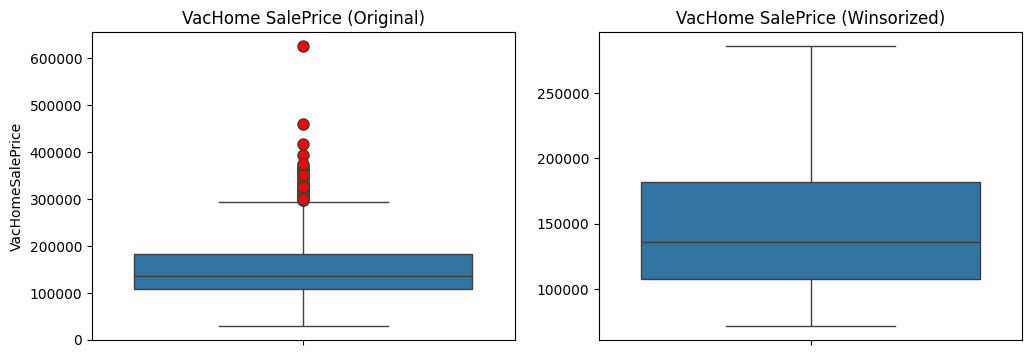

In [ ]:
print_pretty_header("Cleansing Outliers", "Use Winsorization")

# Assuming df_train_data contains the data you want to plot
outlier_column = 'VacHomeSalePrice'
data = df_train_data[outlier_column]

# Set up the figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns
# Define flierprops to customize the appearance of outliers
flierprops = dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none')


# Boxplot without outlier replacement
sns.boxplot(y=data, ax=axes[0], flierprops=flierprops)
axes[0].set_title('VacHome SalePrice (Original)')

# Apply Winsorization to replace outliers
# For example, we'll Winsorize the upper 5% and lower 5% of values
winsorized_data = mstats.winsorize(data, limits=[0.05, 0.05])

# Boxplot with Winsorized data
sns.boxplot(y=winsorized_data, ax=axes[1], flierprops=flierprops)
axes[1].set_title('VacHome SalePrice (Winsorized)')

plt.show()


#### 1.2.3. Drop Columns
> Number of missing values in : VacHomeFireplaceQuality - 47% (690 Observations)



#####**Step 5a:** Drop column with more than 20% data missing.

In [ ]:
droppedColumnName = 'VacHomeFireplaceQuality'
print_pretty_header("Drop Column: " + droppedColumnName, "")

# Print the column count before dropping
print("Column Count Before: ", len(df_train_data.columns))

# Drop the specified column
df_train_data = df_train_data.drop([droppedColumnName], axis=1, errors='ignore')

# Print the column count after dropping
print("Column Count After: ", len(df_train_data.columns))

####################################################################################################

                                Drop Column: VacHomeFireplaceQuality                                

####################################################################################################

Column Count Before:  67
Column Count After:  66


### 1.3. Data Engineering

#### 1.3.1. Data Obfuscation

#####**Step 6a:** Data Obfuscation

In [ ]:
# Assuming you have a DataFrame named 'df_train_data' with a column 'VacHomeOwnerZipcode'

dataObfuscationColumnName = 'VacHomeOwnerZipcode'

# Print a header to indicate the operation
print_pretty_header("Data Obfuscation for : " + dataObfuscationColumnName, "")

# Before obfuscation, print the number of unique values in the 'VacHomeOwnerZipcode' column
unique_values_before = df_train_data[dataObfuscationColumnName].unique()
print("Unique values before obfuscation:" + str(len(unique_values_before)))

# Replace the 'VacHomeOwnerZipcode' column with a masked value
df_train_data[dataObfuscationColumnName] = 'MASKED'

# After obfuscation, print the number of unique values in the 'VacHomeOwnerZipcode' column again
unique_values_after = df_train_data[dataObfuscationColumnName].unique()
print("Unique values after obfuscation:" + str(len(unique_values_after)))


####################################################################################################

                             Data Obfuscation for : VacHomeOwnerZipcode                             

####################################################################################################

Unique values before obfuscation:728
Unique values after obfuscation:1


#### 1.3.2. Data Discretization

#####**Step 6b:** Data Discretization

In [ ]:
# Define the column to discretize
dataDiscretizationColumnName = 'VacHomeSalePrice'

print_pretty_header("Data Discretization for : " + dataDiscretizationColumnName, "")

# Define the number of bins to use for discretization
num_bins = 10

# Create a new column for the discretized data
discrete_col = dataDiscretizationColumnName + '_discrete'
df_train_data[discrete_col] = pd.cut(df_train_data[dataDiscretizationColumnName], num_bins, labels=False)

# Get the value counts for the 'discrete_col' column
value_counts = df_train_data[discrete_col].value_counts()

# Create a dataframe with the 'discrete_col' values and their counts
df_discrete = pd.DataFrame({'Value': df_train_data[discrete_col].unique(), 'Count': value_counts})

# Sort the 'df_discrete' DataFrame by 'Value' in ascending order
df_discrete = df_discrete.sort_values(by='Value', ascending=True)

# Print the 'df_discrete' DataFrame without the index
df_discrete


####################################################################################################

                             Data Discretization for : VacHomeSalePrice                             

####################################################################################################



,Value,Count
VacHomeSalePrice_discrete,,
4,0,31
2,1,181
1,2,347
0,3,79
3,4,75
5,5,13
6,6,2
7,7,1
9,9,1


#### 1.3.3. Data Encoding

#####**Step 6c:** Label Encoding

In [ ]:
# Create a LabelEncoder object
le = LabelEncoder()

dataEncodingColumnName = 'VacHomeDriveway'

# Print Header
print_pretty_header("Data Encoding (LabelEncoding) : " + dataEncodingColumnName, "")

# Encode the "VacHomeDriveway" column and store the result in a new column
df_train_data['VacHomeDriveway_Encoded'] = le.fit_transform(df_train_data[dataEncodingColumnName])

# Get the original and encoded values for "VacHomeFence" as lists
original_values = df_train_data[dataEncodingColumnName].unique().tolist()
encoded_values = df_train_data['VacHomeDriveway_Encoded'].unique().tolist()

print("Original 'VacHomeDriveway' Values as a List:")
print(original_values)

print("\nEncoded 'VacHomeDriveway' Values as a List:")
print(encoded_values)


####################################################################################################

                          Data Encoding (LabelEncoding) : VacHomeDriveway                           

####################################################################################################

Original 'VacHomeDriveway' Values as a List:
['Paved', 'Only Gravel', 'Partially Gravel']

Encoded 'VacHomeDriveway' Values as a List:
[2, 0, 1]


#####**Step 6d:** Ordinal Encoding

In [ ]:
# Define an ordinal mapping for "VacHomeFence" quality levels
fence_mapping = {
    'No Fence': 1,
    'Vinyl Fences': 2,
    'Wood Fences': 3,
    'Composite Fences': 4,
    'Metal Fences': 5
}

# Print Header
print_pretty_header("Data Encoding (Ordinal Encoding) : " + dataEncodingColumnName, "")

# Apply the mapping to create an "OrdinalDriveway" column
df_train_data['VacHomeFence_ordinal'] = df_train_data['VacHomeFence'].map(fence_mapping)

# Print columns values before and after encoding
print("Before Encoding:")
print(df_train_data['VacHomeFence'].unique())

print("\nAfter Encoding:")
print(df_train_data['VacHomeFence_ordinal'].unique())


####################################################################################################

                         Data Encoding (Ordinal Encoding) : VacHomeDriveway                         

####################################################################################################

Before Encoding:
['No Fence' 'Vinyl Fences' 'Wood Fences' 'Composite Fences' 'Metal Fences']

After Encoding:
[1 2 3 4 5]


#####**Step 6e:** One Hot Encoding

In [ ]:
dataEncodingColumnName = 'VacHomeOwnerGender'
# Print Header
print_pretty_header("Data Encoding (One-Hot Encoding) : " + dataEncodingColumnName, "")

# Print column names before one-hot encoding
print("Column names before one-hot encoding:" + dataEncodingColumnName)

# Perform one-hot encoding for "VacHomeOwnerGender" column
df_train_data = pd.get_dummies(df_train_data, columns=[dataEncodingColumnName])

# Add the "_Encoded" suffix to the new column names
df_train_data.columns = [col + '_OneHotEncoded' if col.startswith('VacHomeOwnerGender_') else col for col in df_train_data.columns]

# Print only columns with One hot encoding
encoded_columns = [col for col in df_train_data.columns if col.endswith('_OneHotEncoded')]
print("Columns with '_Encoded' suffix:")
for col in encoded_columns:
    print(col)

####################################################################################################

                       Data Encoding (One-Hot Encoding) : VacHomeOwnerGender                        

####################################################################################################

Column names before one-hot encoding:VacHomeOwnerGender
Columns with '_Encoded' suffix:
VacHomeOwnerGender_F_OneHotEncoded
VacHomeOwnerGender_M_OneHotEncoded
VacHomeOwnerGender_Unknown_OneHotEncoded


#### 1.3.4. Data Normalization


#####**Step 6f:** Data Normalization

In [ ]:
# Select the continuous columns to normalize
dataNormalizationColumnName = ['VacHomeLotSqFt', 'VacHomeBsmtSqFt', 'VacHomeSqFt']

# Convert the list of column names to a comma-separated string
dataNormalizationColumnName_str = ', '.join(dataNormalizationColumnName)

# Print Header
print_pretty_header("Data Normalization for : " + dataNormalizationColumnName_str, "")

# Create a scaler object
scaler = MinMaxScaler()

# Normalize the selected columns in the dataframe and rename the columns
df_normalized = pd.DataFrame(scaler.fit_transform(df_train_data[dataNormalizationColumnName]), columns=[col+'_normalized' for col in dataNormalizationColumnName])

# Replace the original columns with the normalized columns in the dataframe
# df_train_data.drop(dataNormalizationColumnName, axis=1, inplace=True)
df_train_data = pd.concat([df_train_data, df_normalized], axis=1)

# Access the normalized columns in the df_train_data DataFrame
df_normalized_print = df_train_data[['VacHomeLotSqFt_normalized', 'VacHomeBsmtSqFt_normalized', 'VacHomeSqFt_normalized']]

# Print the first few rows of the normalized dataframe
df_normalized_print


####################################################################################################

               Data Normalization for : VacHomeLotSqFt, VacHomeBsmtSqFt, VacHomeSqFt                

####################################################################################################



,VacHomeLotSqFt_normalized,VacHomeBsmtSqFt_normalized,VacHomeSqFt_normalized
0,0.032556,0.266999,0.316905
1,0.037936,0.393637,0.213726
2,0.045655,0.286962,0.334408
3,0.037702,0.235808,0.318517
4,0.059737,0.357143,0.429295
...,...,...,...
725,0.025585,0.269495,0.122064
726,0.094520,0.274485,0.309995
727,0.027242,0.384279,0.206817
728,0.046708,0.494074,0.332105


#### 1.3.5. Data Standardization

#####**Step 6g:** Data Standardization

In [ ]:
# Select the continuous columns to normalize
dataStandardizationColumnName = ['VacHomeSqFt', 'VacHomeSalePrice']

# Convert the list of column names to a comma-separated string
dataStandardizationColumnName_str = ', '.join(dataNormalizationColumnName)

# Print Header
print_pretty_header("Data Standardization for : " + dataStandardizationColumnName_str, "")

# Create a StandardScaler object
scaler = StandardScaler()

# Fit and transform the selected columns using the scaler
df_standardized = pd.DataFrame(scaler.fit_transform(df_train_data[dataStandardizationColumnName]), columns=[col+'_standardized' for col in dataStandardizationColumnName])

# Replace the original columns with the normalized columns in the dataframe
# df_train_data.drop(continuous_cols, axis=1, inplace=True)
df_train_data = pd.concat([df_train_data, df_standardized], axis=1)

df_standardized_print = pd.DataFrame(df_train_data[['VacHomeSqFt', 'VacHomeSalePrice', 'VacHomeSqFt_standardized', 'VacHomeSalePrice_standardized']])

# Print the first few rows of the normalized dataframe
df_standardized_print


####################################################################################################

              Data Standardization for : VacHomeLotSqFt, VacHomeBsmtSqFt, VacHomeSqFt               

####################################################################################################



,VacHomeSqFt,VacHomeSalePrice,VacHomeSqFt_standardized,VacHomeSalePrice_standardized
0,1710,173061.0,0.373822,0.310060
1,1262,150651.0,-0.480390,-0.019917
2,1786,185511.0,0.518733,0.493381
3,1717,116206.0,0.387169,-0.527104
4,2198,207506.0,1.304303,0.817248
...,...,...,...,...
725,864,100021.0,-1.239266,-0.765421
726,1680,184266.0,0.316621,0.475049
727,1232,161441.0,-0.537592,0.138961
728,1776,91306.0,0.499666,-0.893745


#### 1.3.6. Data Smoothing

#####**Step 6h:** Data Smoothing

In [ ]:
# Authenticate and create the PyDrive client.
auth.authenticate_user()                  # Authenticating Colab user
gauth = GoogleAuth()                       # Creating Google authentication object
gauth.credentials = GoogleCredentials.get_application_default()  # Setting credentials
drive = GoogleDrive(gauth)                 # Creating PyDrive client

# Read File
timeseries_link = 'https://drive.google.com/open?id=1vV1mFw3tm9bG7ttsi60H8u6GUiFd_FVu'  # The shareable link#
ignorestr, timeseries_file_id = timeseries_link.split('=') # Extracting file ID from the link
timeseries_file = drive.CreateFile({'id':timeseries_file_id})  # Creating file object using the file ID
timeseries_file.GetContentFile('BTC-USD.csv')   # Downloading the file and saving it with a specific name
df_timeseries_data = pd.read_csv('BTC-USD.csv')  # Reading the downloaded CSV file into a Pandas DataFrame

# Dataset is now stored in a Pandas Dataframe
pd.set_option('display.max_columns', None)
# df_timeseries_data.head()

# rename the column since space in column name creates programming issues
df_timeseries_data.rename(columns={"Adj Close": "Adj_Close"}, inplace=True)
# Find the index of the row with the date Dec 31
dec_31_index = df_timeseries_data[df_timeseries_data['Date'] == '2019-12-31'].index

# Delete the row at that index
df_timeseries_data = df_timeseries_data.drop(dec_31_index)

# Verify that the row has been deleted
# print(df_timeseries_data[df_timeseries_data['Date'] == '2019-12-31'])

# Split the data into training and test sets with a 80/20 split
df_timeseries_train_data, df_timeseries_test_data = train_test_split(df_timeseries_data, test_size=0.2, shuffle=False)

# Split the training data into training and validation sets with a 75/25 split
df_timeseries_train_data, df_timeseries_validation_data = train_test_split(df_timeseries_train_data, test_size=0.25, shuffle=False)

# Print the sizes of the three sets
print("Training data size:", len(df_timeseries_train_data))
print("Validation data size:", len(df_timeseries_validation_data))
print("Test data size:", len(df_timeseries_test_data))


Training data size: 720
Validation data size: 240
Test data size: 241


In [ ]:
# Smooth the data

# Define window size for Simple Moving Average - we use a rolling period of 7
window_size = 7

# Apply SMA smoothing to Adj_Close column in training data
df_timeseries_train_data["Adj_Close_SMA"] = df_timeseries_train_data["Adj_Close"].rolling(window=window_size).mean()

df_timeseries_train_data


,Date,Open,High,Low,Close,Adj_Close,Volume,Adj_Close_SMA
0,2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,6985.470215,2.080208e+10,NaN
1,2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,7344.884277,2.811148e+10,NaN
2,2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,7410.656738,1.844427e+10,NaN
3,2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,7411.317383,1.972507e+10,NaN
4,2020-01-06,7410.452148,7781.867188,7409.292969,7769.219238,7769.219238,2.327626e+10,NaN
...,...,...,...,...,...,...,...,...
715,2021-12-17,47653.730469,48004.894531,45618.214844,46202.144531,46202.144531,3.290273e+10,47939.321429
716,2021-12-18,46219.253906,47313.828125,45598.441406,46848.777344,46848.777344,2.609829e+10,47580.217076
717,2021-12-19,46853.867188,48089.664063,46502.953125,46707.015625,46707.015625,2.515405e+10,47095.742746
718,2021-12-20,46707.062500,47401.718750,45579.808594,46880.277344,46880.277344,3.096190e+10,47116.142299


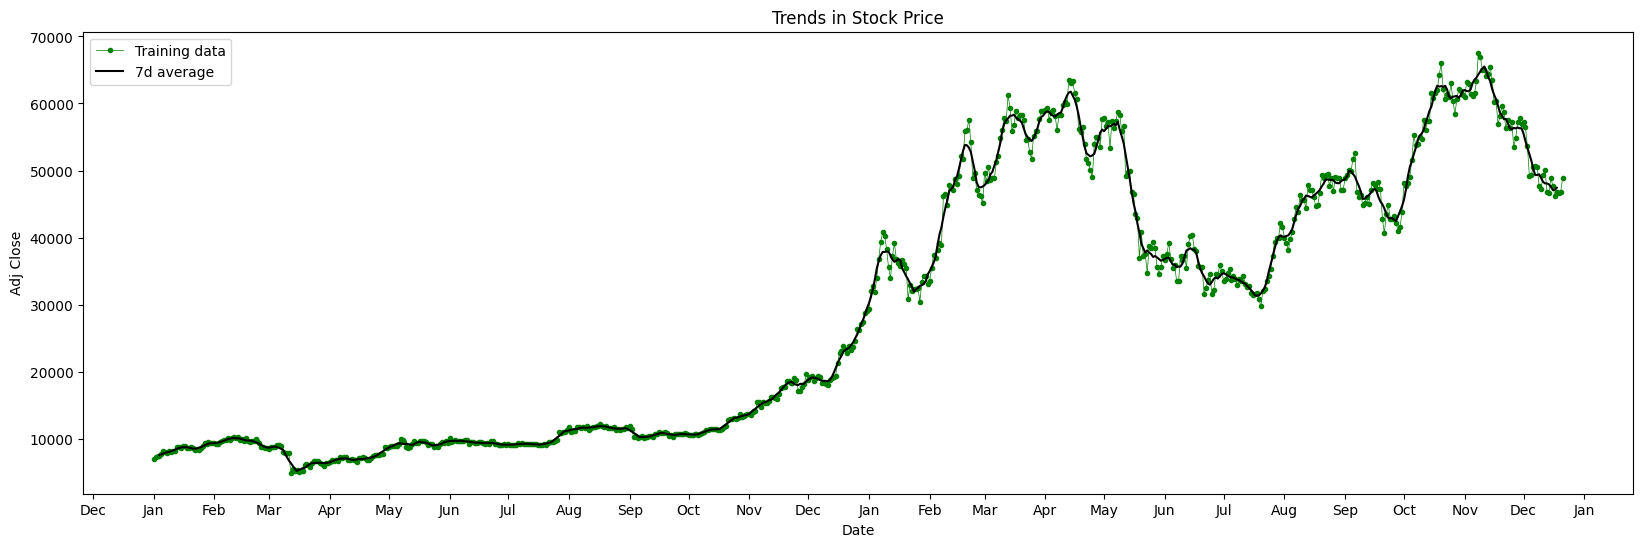

In [ ]:
from matplotlib.dates import MonthLocator, DateFormatter

fig, ax = plt.subplots(figsize=(20, 6))

df_7d = df_timeseries_train_data['Adj_Close'].rolling(7, center=True).mean()

ax.plot(df_timeseries_train_data.Date, df_timeseries_train_data.Adj_Close, color='green' , marker='.', linestyle='-', linewidth=0.5, label='Training data')
ax.plot(df_timeseries_train_data.Date, df_7d, color='black' , marker='', markersize=4, linestyle='-', label='7d average')

ax.legend()
ax.set_xlabel('Date')
ax.set_ylabel('Adj Close')
ax.set_title('Trends in Stock Price')

# Show only every 7th date on the x-axis
# formatters' options
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b'))

plt.show()


#### 1.3.7. Data Transformations

#####**Step 6i:** Data Transformations

In [ ]:
# Print Header
print_pretty_header("Data Transformations" , "")

# Apply a log transformation to the SalePrice column
df_train_data['VacHomeSqFt_log'] = np.log(df_train_data['VacHomeSqFt'])
df_train_data['VacHomeSalePrice_log'] = np.log(df_train_data['VacHomeSalePrice'])

# Print the original and transformed data
df_log_print = pd.DataFrame(df_train_data[['VacHomeSqFt', 'VacHomeSalePrice', 'VacHomeSqFt_log', 'VacHomeSalePrice_log']])

# Print the first few rows of the normalized dataframe
df_log_print

####################################################################################################

                                        Data Transformations                                        

####################################################################################################



,VacHomeSqFt,VacHomeSalePrice,VacHomeSqFt_log,VacHomeSalePrice_log
0,1710,173061.0,7.444249,12.061399
1,1262,150651.0,7.140453,11.922721
2,1786,185511.0,7.487734,12.130869
3,1717,116206.0,7.448334,11.663120
4,2198,207506.0,7.695303,12.242916
...,...,...,...,...
725,864,100021.0,6.761573,11.513135
726,1680,184266.0,7.426549,12.124136
727,1232,161441.0,7.116394,11.991895
728,1776,91306.0,7.482119,11.421972


### 1.4. Data Reduction

#### 1.4.1. Data Aggregation

#####**Step 7a:** Data Aggregation

In [ ]:
# Print Header
print_pretty_header("Data Aggregation" , "")

# Group by VacHomeClass and calculate sum VacHomeSalePrice for each group
agg_df = df_train_data.groupby('VacHomeClass')['VacHomeSalePrice'].sum()

# Convert the aggregated data to a DataFrame
agg_df = pd.DataFrame(agg_df).reset_index()

# Print the aggregated data as a DataFrame
agg_df

####################################################################################################

                                          Data Aggregation                                          

####################################################################################################



,VacHomeClass,VacHomeSalePrice
0,VacHomeClass-1,41736051.08
1,VacHomeClass-10,986088.00
2,VacHomeClass-11,2059477.63
3,VacHomeClass-12,7687792.44
4,VacHomeClass-13,3464102.00
5,VacHomeClass-14,469816.00
6,VacHomeClass-15,2067976.00
7,VacHomeClass-2,2900574.83
8,VacHomeClass-3,192157.00
9,VacHomeClass-4,878698.00


#### 1.4.2. Numerosity Reduction

#####**Step 7b:** Numerosity Reduction

In [ ]:
# Print Header
print_pretty_header("Numerosity Reduction" , "")

# initialize the k-means clustering algorithm with 10 clusters
kmeans = KMeans(n_clusters=10)

# fit the algorithm to the data
kmeans.fit(df_train_data[['VacHomeSqFt']])

# get the cluster labels for each data point
labels = kmeans.labels_

# assign the cluster labels to a new column in the dataframe
df_train_data['VacHomeSqFt_cluster'] = labels

# Print the original and transformed data
df_numerosity_reduction_print = pd.DataFrame(df_train_data[['VacHomeSqFt', 'VacHomeSqFt_cluster']])

# Get the frequency of each cluster label
cluster_freq = df_train_data['VacHomeSqFt_cluster'].value_counts()

# Print the frequency as a DataFrame
cluster_freq_df = pd.DataFrame({'Cluster': cluster_freq.index, 'Frequency': cluster_freq.values})
cluster_freq_df

####################################################################################################

                                        Numerosity Reduction                                        

####################################################################################################



,Cluster,Frequency
0,5,122
1,3,120
2,0,119
3,9,109
4,1,91
5,8,71
6,6,50
7,2,37
8,7,9
9,4,2


#### 1.4.3. Data Compression

In [ ]:
# # Define the input and output file paths
# input_file = 'input.txt'
# output_file = 'output.txt.gz'

# # Open the input file and read the content
# with open(input_file, 'rb') as f_in:
#     content = f_in.read()

# # Compress the content using gzip
# compressed_content = gzip.compress(content)

# # Open the output file and write the compressed content
# with gzip.open(output_file, 'wb') as f_out:
#     f_out.write(compressed_content)


In [ ]:
# #write output to Colab
# file_name = "book_fake_dataprep_train_data.csv"

# # Write the DataFrame to a CSV file
# df_train_data.to_csv(file_name, sep=',', encoding='utf-8', index=False)

# # Download the file from the Colab VM to the local PC
# from google.colab import files
# files.download(file_name)


In [ ]:
# # # iterating the columns
# for col in df_train_data.columns:
#     print(col)

------------- End of S2_Ch6_Data_Quality_Engineering Chapter Code ------------ Vidya Subramanian ------------------